In [2]:
import gspread
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from google.oauth2.service_account import Credentials
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [ ]:
SERVICE_ACCOUNT_FILE = '../key/credentials.json'
SCOPES = ['https://www.googleapis.com/auth/spreadsheets',
          'https://www.googleapis.com/auth/drive']
creds = Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE, scopes=SCOPES
)
client = gspread.authorize(creds)

sheet = client.open('alika_transfer').worksheet('user_send_image')
data = sheet.get_all_records()

df = pd.DataFrame(data[0:], columns=data[0])

In [15]:
# New data summary
new_rows = 5
added_date = '28/08'  # Replace with the date when the rows were added.
total_rows = len(df)
previous_total_rows = total_rows - new_rows

summary = pd.DataFrame({
    'Metric': [
        'Added date',
        'New rows added',
        'Rows before addition',
        'Total rows after addition'
    ],
    'Value': [
        added_date,
        new_rows,
        previous_total_rows,
        total_rows
    ]
})

summary

,Metric,Value
0,Added date,28/08
1,New rows added,5
2,Rows before addition,152
3,Total rows after addition,157


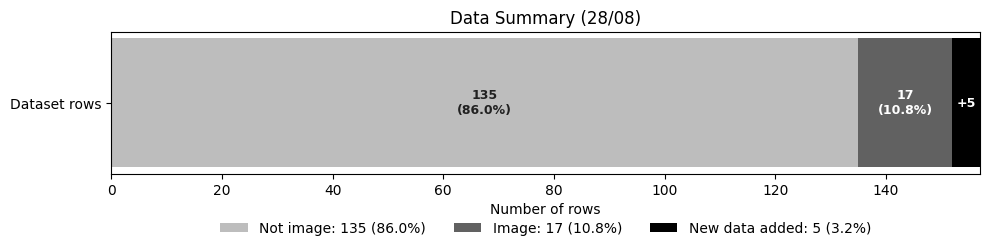

In [19]:
# Visualize all rows in one stacked bar
normalized_values = df.astype('string').apply(
    lambda column: column.str.strip().str.lower()
)
image_mask = normalized_values.eq('image').any(axis=1)

existing_image_count = int(image_mask.iloc[:previous_total_rows].sum())
existing_not_image_count = previous_total_rows - existing_image_count
category_counts = {
    'Not image': existing_not_image_count,
    'Image': existing_image_count,
    'New data added': new_rows
}
category_percentages = {
    category: (count / total_rows) * 100 if total_rows else 0
    for category, count in category_counts.items()
}

fig, ax = plt.subplots(figsize=(10, 2.8))

# Three grayscale levels: not image, image, and newly added data.
ax.barh(
    ['Dataset rows'],
    [existing_not_image_count],
    color='#BDBDBD',
    label=f"Not image: {existing_not_image_count} ({category_percentages['Not image']:.1f}%)"
)
ax.barh(
    ['Dataset rows'],
    [existing_image_count],
    left=[existing_not_image_count],
    color='#616161',
    label=f"Image: {existing_image_count} ({category_percentages['Image']:.1f}%)"
)
ax.barh(
    ['Dataset rows'],
    [new_rows],
    left=[previous_total_rows],
    color='#000000',
    label=f"New data added: {new_rows} ({category_percentages['New data added']:.1f}%)"
)

ax.set_title(f'Data Summary ({added_date})')
ax.set_xlabel('Number of rows')
ax.set_xlim(0, total_rows)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=False)

# Show percentages inside segments when the label can fit clearly.
segment_details = [
    (0, existing_not_image_count, 'Not image'),
    (existing_not_image_count, existing_image_count, 'Image'),
    (previous_total_rows, new_rows, 'New data added')
]
for start, count, category in segment_details:
    if count:
        label = f"{category_percentages[category]:.1f}%"
        if count >= 8:
            label = f'{count}\n({label})'
        elif category == 'New data added':
            label = f'+{count}'
        ax.text(
            start + count / 2,
            0,
            label,
            ha='center',
            va='center',
            color='white' if category != 'Not image' else '#212121',
            fontweight='bold',
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [4]:
# Get Indonesian stopwords
factory = StopWordRemoverFactory()
stop_words = set(factory.get_stop_words())

# Stopwords
custome_stopwords = {
    'yg', 'nya', 'ga', 'gak', 'nggak',
    'udah', 'aja', 'sih', 'dong', 'nih'
}

In [5]:
# Stemming
factory = StemmerFactory()
stemmer = factory.create_stemmer()

df['Background ID clean'] = (
    df['Background ID']
    .fillna('')
    .astype(str)
    .apply(stemmer.stem)
)

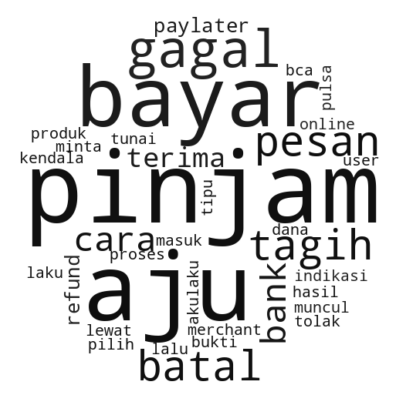

In [6]:
# circle mask
x, y = np.ogrid[:500, :500]
center_x, center_y = 250, 250
radius = 250

mask = ((x - center_x) ** 2 + (y - center_y) ** 2 > radius ** 2) * 255
mask = mask.astype(int)

# wordcloud
text = ' '.join(
    df['Background ID clean']
    .dropna()
    .astype(str)
    .tolist()
)

colors = ["#000000", "#111111", "#101010", "#121212", "#212121", "#222222"]
cmap = LinearSegmentedColormap.from_list("mycmap", colors)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stop_words,
    mask=mask,
    colormap=cmap
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

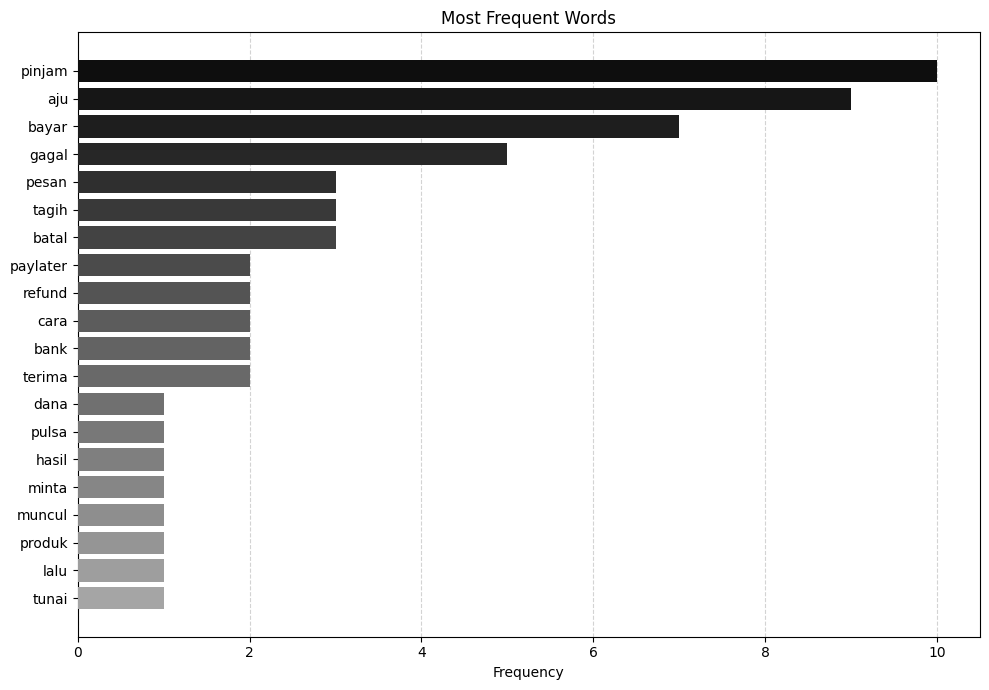

In [9]:
# Count cleaned words for the bar chart
all_stopwords = stop_words | custome_stopwords
top_words = (
    df['Background ID clean']
    .str.lower()
    .str.split()
    .explode()
    .loc[lambda words: words.notna() & ~words.isin(all_stopwords) & (words != '')]
    .value_counts()
    .head(20)
    .rename_axis('Word')
    .reset_index(name='Frequency')
    .sort_values('Frequency')
)

# Generate black to gray gradient
bar_colors = plt.cm.Greys(
    np.linspace(0.45, 0.95, len(top_words))
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_words['Word'],
    top_words['Frequency'],
    color=bar_colors,
    zorder=3
)

# Grid behind bars
ax.set_axisbelow(True)
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.55
)

ax.set_xlabel('Frequency')
ax.set_title('Most Frequent Words')

plt.tight_layout()
plt.show()

### Counting kula

In [ ]:
df_1_5
df_6_10
df_11_14
df_13_15 = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1787219325 (13-15 aug).csv')
df_16_18 = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1787025549 (16-18 aug).csv')
df_19_20 = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1787219503 (19-20 aug).csv')
df_21_26 
df_27_31 = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788141789 (27-31 aug).csv')

In [ ]:
df_merged = pd.concat([df_13_15, df_16_18, df_19_20], ignore_index=True)
df_merged

,business,id,currentAccount,userId,shopid,summary_type,summary_classify,ticketid,Category 1,Category 2,...,qc_score,time_out,question_category1,question_category2,total_message,user_send_message,cs_send_message,changeFlag,autoTransferType,是否转接
0,AFI,2-109205950-3-1_1786627958,3-1-3580648349055650818,109205950,1,NaN,NaN,24197277,Akulaku Paylater (Internal) (NEW),Tagihan & Pembayaran,...,NaN,NaN,NaN,NaN,32,18,14,NaN,NaN,有转接
1,BLANK,2-119278419-3-1_1786776743,3-1-3963127825670286338,119278419,1,NaN,NaN,24207600,PDL,Pengajuan Pinjaman,...,NaN,NaN,NaN,NaN,17,9,8,NaN,NaN,没有转接
2,BLANK,2-12159734-3-1_1786739396,3-1-robot2,12159734,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6,3,3,NaN,NaN,没有转接
3,BLANK,2-123191320-3-1_1786649837,3-1-3425,123191320,1,NaN,NaN,24198610,Dana Cicil (Large Loan),Collection,...,NaN,NaN,NaN,NaN,38,22,16,NaN,NaN,没有转接
4,BLANK,2-127691082-3-1_1786762291,3-1-robot2,127691082,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4,2,2,NaN,NaN,没有转接
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139361,AFI,2-63052327-3-1_1787113160,3-1-robot2,63052327,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,12,6,6,NaN,NaN,没有转接
139362,BLANK,2-73006738-3-1_1787108287,3-1-robot2,73006738,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4,2,2,NaN,NaN,没有转接
139363,AFI,2-9192189-3-1_1787145889,3-1-3560,9192189,1,NaN,NaN,24232829,General (NEW),Transfer Call/Chat Ke ASI,...,NaN,NaN,NaN,NaN,13,8,5,NaN,NaN,有转接
139364,BLANK,2-92661019-3-1_1787153797,3-1-3986481067942742018,92661019,1,NaN,NaN,24233550,Dana Cicil (Large Loan),Pengajuan Pinjaman,...,NaN,NaN,NaN,NaN,20,8,12,NaN,NaN,没有转接


In [ ]:
df_sanitized = df_merged[(df_merged['business'] != 'AFI') & ((df_merged['currentAccount'] == '3-1-robot') | (df_merged['currentAccount'] == '3-1-robot2'))]

In [ ]:
df_sanitized

,business,id,currentAccount,userId,shopid,summary_type,summary_classify,ticketid,Category 1,Category 2,...,qc_score,time_out,question_category1,question_category2,total_message,user_send_message,cs_send_message,changeFlag,autoTransferType,是否转接
2,BLANK,2-12159734-3-1_1786739396,3-1-robot2,12159734,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6,3,3,NaN,NaN,没有转接
4,BLANK,2-127691082-3-1_1786762291,3-1-robot2,127691082,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4,2,2,NaN,NaN,没有转接
5,BLANK,2-12881851-3-1_1786698299,3-1-robot2,12881851,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5,2,3,NaN,NaN,没有转接
6,BLANK,2-130747133-3-1_1786670777,3-1-robot2,130747133,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,12,5,7,NaN,NaN,没有转接
8,BLANK,2-135146244-3-1_1786593751,3-1-robot2,135146244,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4,2,2,NaN,NaN,没有转接
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139358,BLANK,2-2063024742-3-1_1787156346,3-1-robot2,2063024742,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4,2,2,NaN,NaN,没有转接
139359,BLANK,2-2063029222-3-1_1787108930,3-1-robot2,2063029222,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4,2,2,NaN,NaN,没有转接
139360,BLANK,2-2173387-3-1_1787100581,3-1-robot2,2173387,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4,2,2,NaN,NaN,没有转接
139362,BLANK,2-73006738-3-1_1787108287,3-1-robot2,73006738,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4,2,2,NaN,NaN,没有转接
